## Task 4: Latent Space Analysis and Error Inspection

In this task, you will analyze the internal feature representation learned by the best model obtained in Task 3. Deep neural networks transform input images into increasingly abstract representations through multiple layers. The output of the final hidden layer before the classification layer can be interpreted as a latent feature representation of the images.

By visualizing this latent space, it is possible to gain insights into how the model organizes the data and why certain samples may be misclassified.

Create a new notebook named `latentspace.ipynb`. Use the best performing model from Task 3.

### 1. Load the trained model
- Load the best model obtained.
- Ensure the model is set to evaluation mode.
- Modify the network so that it outputs the feature vector from the last hidden layer instead of the final classification layer.

### 2. Extract latent representations
- Pass all images from the validation or test dataset through the model.
- For each image, extract the latent feature vector from the last hidden layer.
- Store for each sample:
  - the (flattened) latent feature vector,
  - the ground-truth label,
  - the predicted label,
  - the prediction confidence.

### 3. Dimensionality reduction
- Since the latent vectors are high-dimensional, reduce their dimensionality to two dimensions for visualization.
- Apply the following methods:
  - PCA
  - t-SNE
- Plot the 2D latent space obtained with both methods.
- Color the samples according to their ground-truth class label.

### 4. Comparison of PCA and t-SNE
- Compare the latent space structure obtained with PCA and t-SNE.
- Investigate whether the classes appear more clearly separated with one method than the other.

### 5. Inspection of misclassified samples
- Display several misclassified test images along with:
  - their ground-truth label,
  - the predicted label,
  - the prediction confidence.
- Compare these samples with nearby correctly classified samples in the latent space.

---

In your report, discuss the results of this analysis and address the following points:

- **Latent space structure:** Do healthy knees and severe osteoarthritis cases form distinct clusters in the latent space?
- **Dimensionality reduction methods:** What differences do you observe between the PCA and t-SNE visualizations? Describe your observations regarding the latent space structure.
- **Misclassified samples:** Where do misclassified samples appear in the latent space?
- **Interpretation:** What can these observations tell you about the model's behavior and the intrinsic difficulty of the classification task?

# 1. Select a Trained Classifier — Baseline CNN

We use the best-performing baseline CNN from Task 2 (lr=0.001, dropout=0.5, trained on train+val, 30 epochs).

In [1]:
import sys

sys.path.insert(0, "../0_generalcode")
from gpu_helper import settest_torch_gpu

device = settest_torch_gpu()

PyTorch CUDA available: True
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
Keras backend: tensorflow
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Prediction shape: (5, 1)  — Keras is running on tensorflow , device: cuda


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import f1_score, accuracy_score
import os

In [3]:
from pipeline_helper import MyPreprocess

DATA_DIR = "../../data/1_source/"

test_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "test"), transform=MyPreprocess()
)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Test samples: {len(test_dataset)}")
print(f"Classes: {test_dataset.classes}")

Test samples: 146
Classes: ['0', '1']


In [4]:
from model_helper import BaselineCNN

MODEL_PATH = "../2_basemodel/baseline_model.pth"
model = BaselineCNN.load(MODEL_PATH, device)
print("Model loaded successfully!")

Model loaded successfully!


In [5]:
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images).squeeze(1)
        probs = torch.sigmoid(outputs)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds = (all_probs >= 0.5).astype(int)

print(f"Test samples: {len(all_labels)}")
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print(f"F1 Score: {f1_score(all_labels, all_preds):.4f}")

Test samples: 146
Accuracy: 0.9452
F1 Score: 0.9184


In [6]:
# setting the global colors and labels used for analysis
CLASS_VALUES = [0, 1]
CLASS_NAMES = ["Healthy", "OA"]
CLASS_COLORS = ["blue", "red"]

# 2. Extract Latent Representations

The **last hidden layer** is the 128-dimensional ReLU output exposed by  --
the representation the network builds just before the final classification head.

In [7]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors

In [8]:
all_features = []

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        feats = model.latent(images)  # use the latent layer of our model
        all_features.extend(feats.cpu().numpy())

all_features = np.array(all_features)  # (N, 128)
print(f"Feature matrix: {all_features.shape}")
print(f"Labels shape  : {all_labels.shape}")

Feature matrix: (146, 128)
Labels shape  : (146,)


In [9]:
# normalize the features
from sklearn.preprocessing import StandardScaler

features_scaled = StandardScaler().fit_transform(all_features)

## Feature Matrix Visualisation

Two complementary views of the `(146, 128)` latent feature matrix:

- **Heatmap** — each row is one sample (sorted by class), each column is one of the 128 latent features. Colour = standardised activation. Reveals which feature blocks fire differently per class.
- **Mean activation per feature** — average activation of each feature dimension for Healthy vs OA samples. Highlights the most discriminative dimensions.

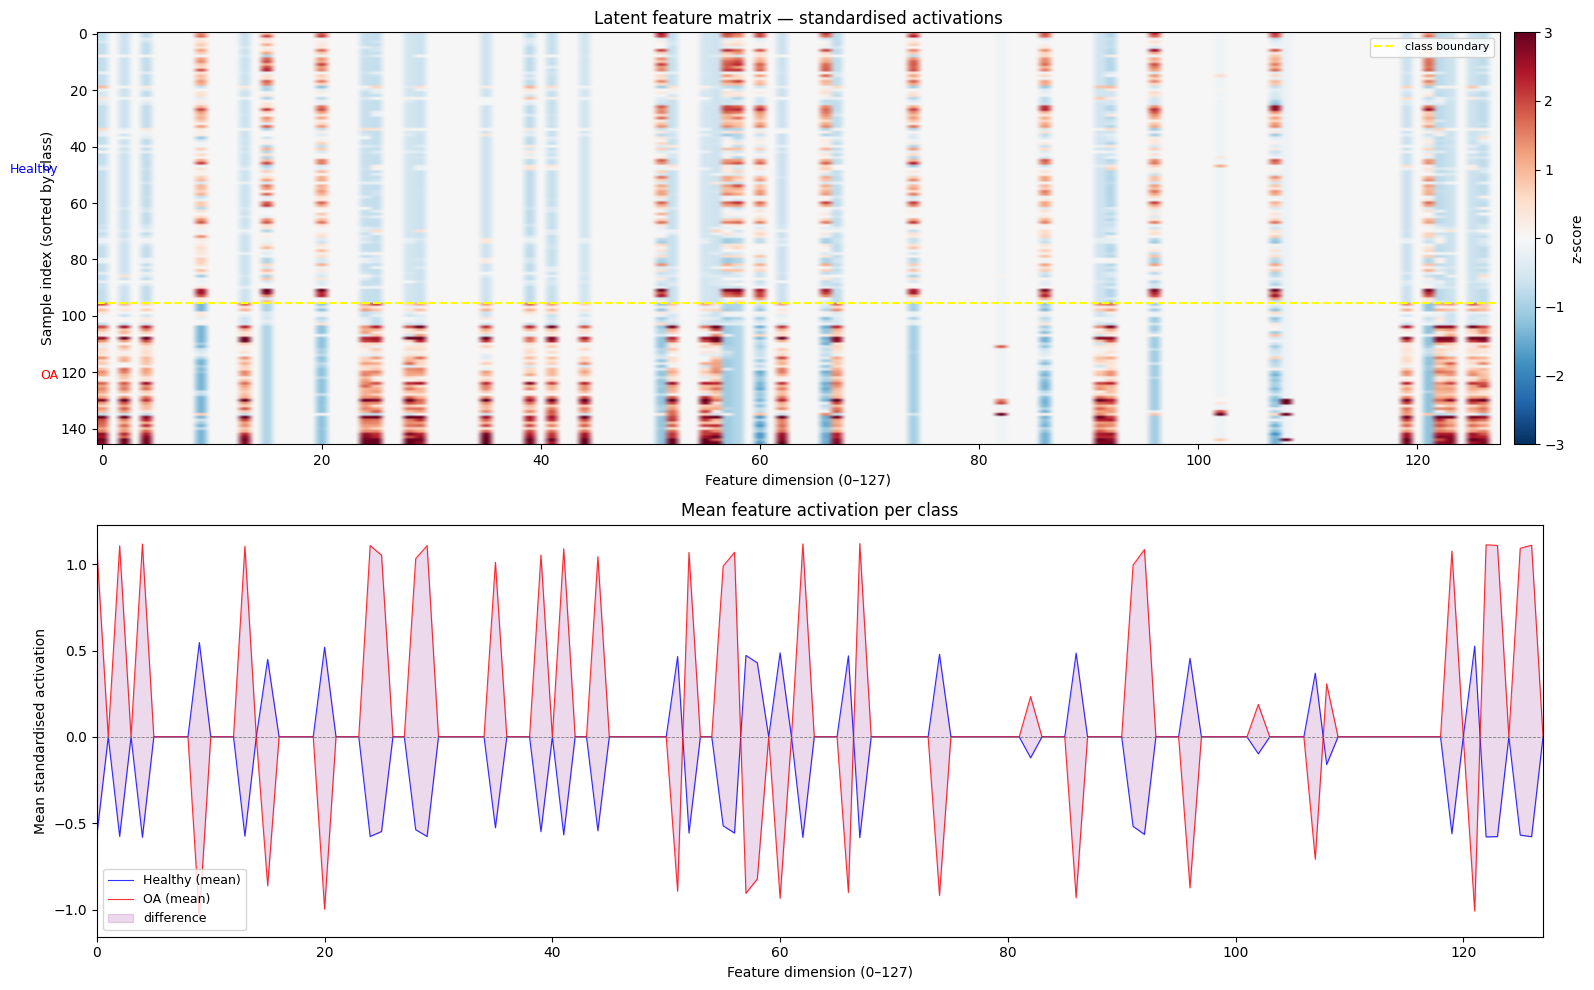

In [10]:
# sort samples by ground-truth label so classes appear as distinct bands
sort_idx = np.argsort(all_labels)
sorted_features = features_scaled[sort_idx]
sorted_labels = all_labels[sort_idx]

# boundary between class 0 and class 1
class_boundary = np.searchsorted(sorted_labels, 1)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# --- heatmap ---
ax = axes[0]
im = ax.imshow(sorted_features, aspect="auto", cmap="RdBu_r", vmin=-3, vmax=3)
ax.axhline(
    class_boundary - 0.5,
    color="yellow",
    linewidth=1.5,
    linestyle="--",
    label="class boundary",
)
ax.set_xlabel("Feature dimension (0–127)")
ax.set_ylabel("Sample index (sorted by class)")
ax.set_title("Latent feature matrix — standardised activations")
ax.legend(loc="upper right", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.02, pad=0.01, label="z-score")

n0 = class_boundary
n1 = len(sorted_labels) - class_boundary
ax.text(
    -4,
    n0 / 2,
    CLASS_NAMES[0],
    va="center",
    ha="right",
    fontsize=9,
    color=CLASS_COLORS[0],
    clip_on=False,
)
ax.text(
    -4,
    n0 + n1 / 2,
    CLASS_NAMES[1],
    va="center",
    ha="right",
    fontsize=9,
    color=CLASS_COLORS[1],
    clip_on=False,
)

# --- mean activation per feature per class ---
ax2 = axes[1]
x = np.arange(features_scaled.shape[1])
means = [
    features_scaled[all_labels == cls].mean(axis=0) for cls in range(len(CLASS_NAMES))
]

for cls, (name, color, mean) in enumerate(zip(CLASS_NAMES, CLASS_COLORS, means)):
    ax2.plot(x, mean, color=color, alpha=0.8, linewidth=0.8, label=f"{name} (mean)")

ax2.fill_between(x, means[0], means[1], alpha=0.15, color="purple", label="difference")
ax2.axhline(0, color="gray", linewidth=0.6, linestyle="--")
ax2.set_xlabel("Feature dimension (0–127)")
ax2.set_ylabel("Mean standardised activation")
ax2.set_title("Mean feature activation per class")
ax2.legend(fontsize=9)
ax2.set_xlim(0, features_scaled.shape[1] - 1)

plt.tight_layout()
plt.show()

## Feature Importance

Two complementary metrics for each of the 128 latent dimensions:

| Metric | What it measures |
|---|---|
| **Mean absolute difference** | Raw activation gap between classes (same scale as the features) |
| **Cohen's d** | Standardised effect size — accounts for within-class spread, so features with a large gap *and* low variance score highest |

Top-20 features are plotted for each metric. High overlap between the two rankings indicates robust discriminative dimensions.

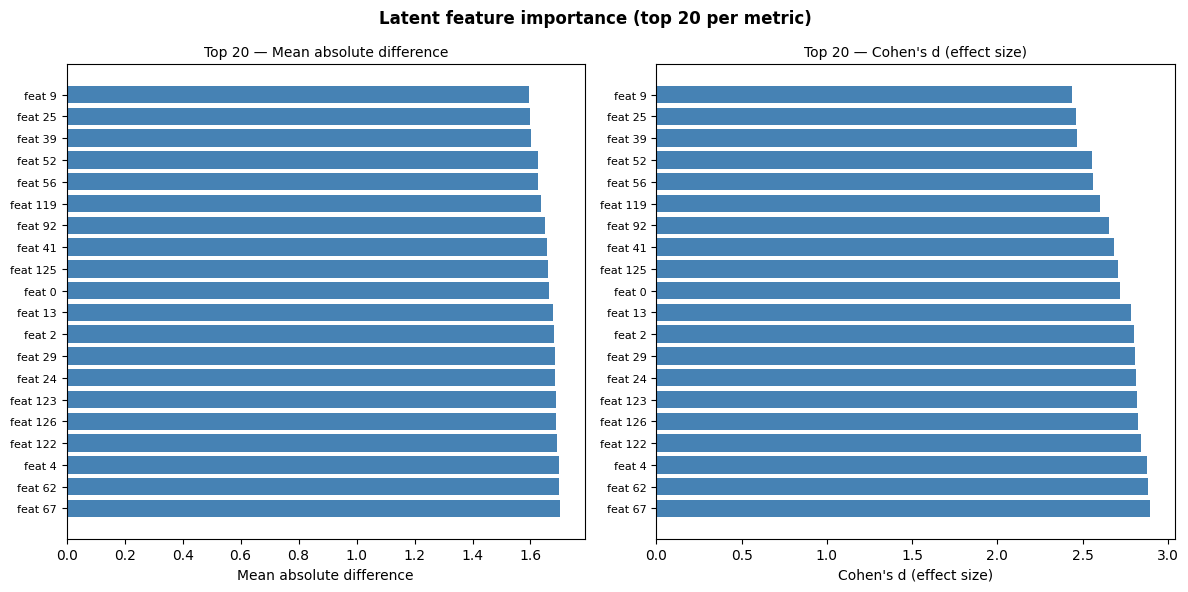

Features in top-20 for both metrics (20): [np.int64(0), np.int64(2), np.int64(4), np.int64(9), np.int64(13), np.int64(24), np.int64(25), np.int64(29), np.int64(39), np.int64(41), np.int64(52), np.int64(56), np.int64(62), np.int64(67), np.int64(92), np.int64(119), np.int64(122), np.int64(123), np.int64(125), np.int64(126)]


In [11]:
feats_per_class = [features_scaled[all_labels == cls] for cls in CLASS_VALUES]
top_n = 20

# --- metric 1: mean absolute difference ---
mean_diff = np.abs(means[0] - means[1])

# --- metric 2: Cohen's d (standardised effect size) ---
pooled_std = np.sqrt(
    (
        (feats_per_class[0].shape[0] - 1) * feats_per_class[0].var(axis=0)
        + (feats_per_class[1].shape[0] - 1) * feats_per_class[1].var(axis=0)
    )
    / (features_scaled.shape[0] - 2)
)
cohens_d = np.abs(means[0] - means[1]) / (pooled_std + 1e-8)

metrics = [
    ("Mean absolute difference", mean_diff),
    ("Cohen's d (effect size)", cohens_d),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, (title, scores) in zip(axes, metrics):
    top_idx = np.argsort(scores)[::-1][:top_n]
    top_scores = scores[top_idx]

    ax.barh(range(top_n), top_scores[::-1], color="steelblue", edgecolor="none")
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([f"feat {i}" for i in top_idx[::-1]], fontsize=8)
    ax.set_xlabel(title)
    ax.set_title(f"Top {top_n} — {title}", fontsize=10)
    ax.invert_yaxis()

plt.suptitle("Latent feature importance (top 20 per metric)", fontweight="bold")
plt.tight_layout()
plt.show()

# features that rank in the top-20 for both metrics
top_sets = [set(np.argsort(s)[::-1][:top_n]) for _, s in metrics]
consensus = top_sets[0] & top_sets[1]
print(
    f"Features in top-{top_n} for both metrics ({len(consensus)}): {sorted(consensus)}"
)

# 3. Dimensionality Reduction

We reduce the 128-dim latent vectors to 2D with **PCA** and **t-SNE** and
plot both embeddings coloured by ground-truth label.
Misclassified samples are additionally marked with a black cross (X).

In [12]:
pca = PCA(n_components=2, random_state=42)
feats_pca = pca.fit_transform(features_scaled)
print(
    f"PCA explained variance: {pca.explained_variance_ratio_.round(3)} "
    f"(total {pca.explained_variance_ratio_.sum():.1%})"
)

PCA explained variance: [0.741 0.119] (total 86.0%)


In [13]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
feats_tsne = tsne.fit_transform(features_scaled)
tsne.fit_transform(features_scaled)
print("t-SNE done")

t-SNE done


add some t-SNE evaluation metrics

In [14]:
from sklearn.manifold import trustworthiness

# ranges from 0 → 1 (1 = optimal)
t = trustworthiness(features_scaled, feats_tsne, n_neighbors=10)
print(t)

0.9809321366713903


In [15]:
from sklearn.metrics import silhouette_score

score = silhouette_score(feats_tsne, all_labels)
print(score)

0.5396380424499512


#### Visual comparison

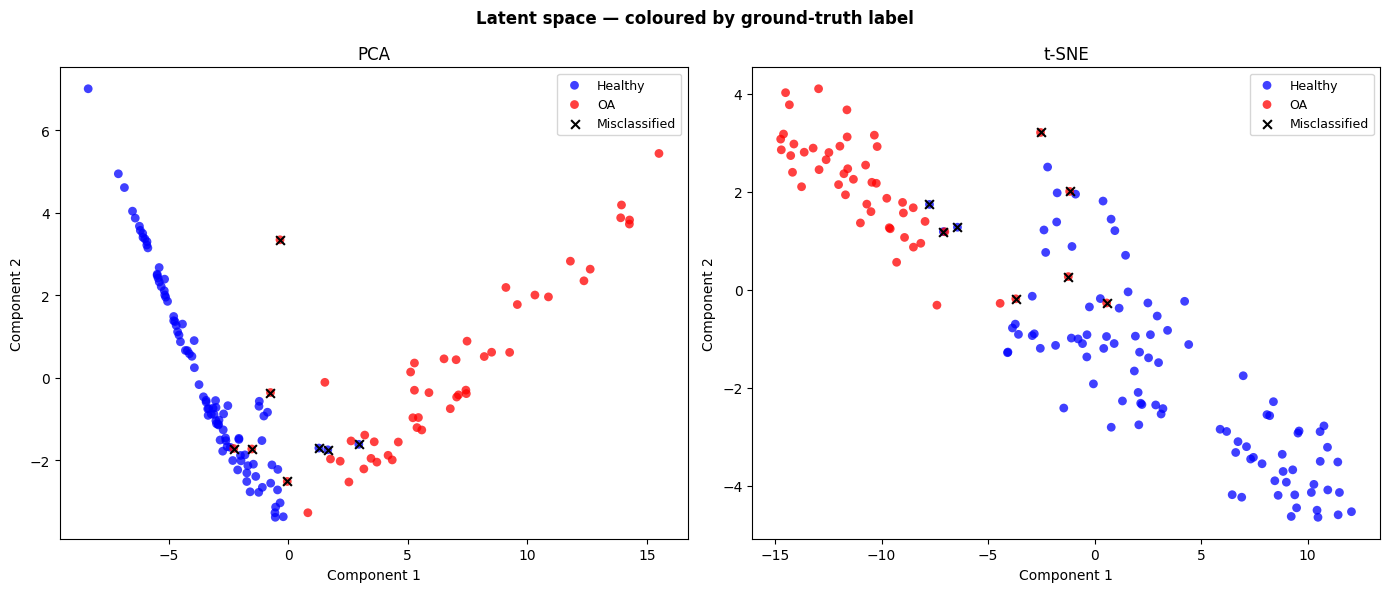

In [16]:
misc_mask = all_labels != all_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (emb, title) in zip(axes, [(feats_pca, "PCA"), (feats_tsne, "t-SNE")]):
    for cls, name, color in zip(CLASS_VALUES, CLASS_NAMES, CLASS_COLORS):
        m = all_labels == cls
        ax.scatter(
            emb[m, 0],
            emb[m, 1],
            c=color,
            label=name,
            alpha=0.75,
            s=40,
            edgecolors="none",
        )
    ax.scatter(
        emb[misc_mask, 0],
        emb[misc_mask, 1],
        marker="x",
        c="black",
        s=40,
        zorder=5,
        label="Misclassified",
    )
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

plt.suptitle("Latent space — coloured by ground-truth label", fontweight="bold")
plt.tight_layout()
plt.show()

## Parameter Sweep

### t-SNE Perplexity
Perplexity controls the balance between local and global neighbourhood structure.
Low values (5–10) emphasise tight local clusters; high values (30–50) reveal broader global topology.
Recommended range: 5–50, rule of thumb ≈ √N (here √146 ≈ 12).

### PCA — optimal n_components
Rather than comparing t-SNE plots with different pre-reduction sizes (which rarely differ visually),
we evaluate how many PCA components are needed to retain a given fraction of the total variance.
The **scree plot** shows variance per component; the **cumulative curve** shows the threshold crossings.

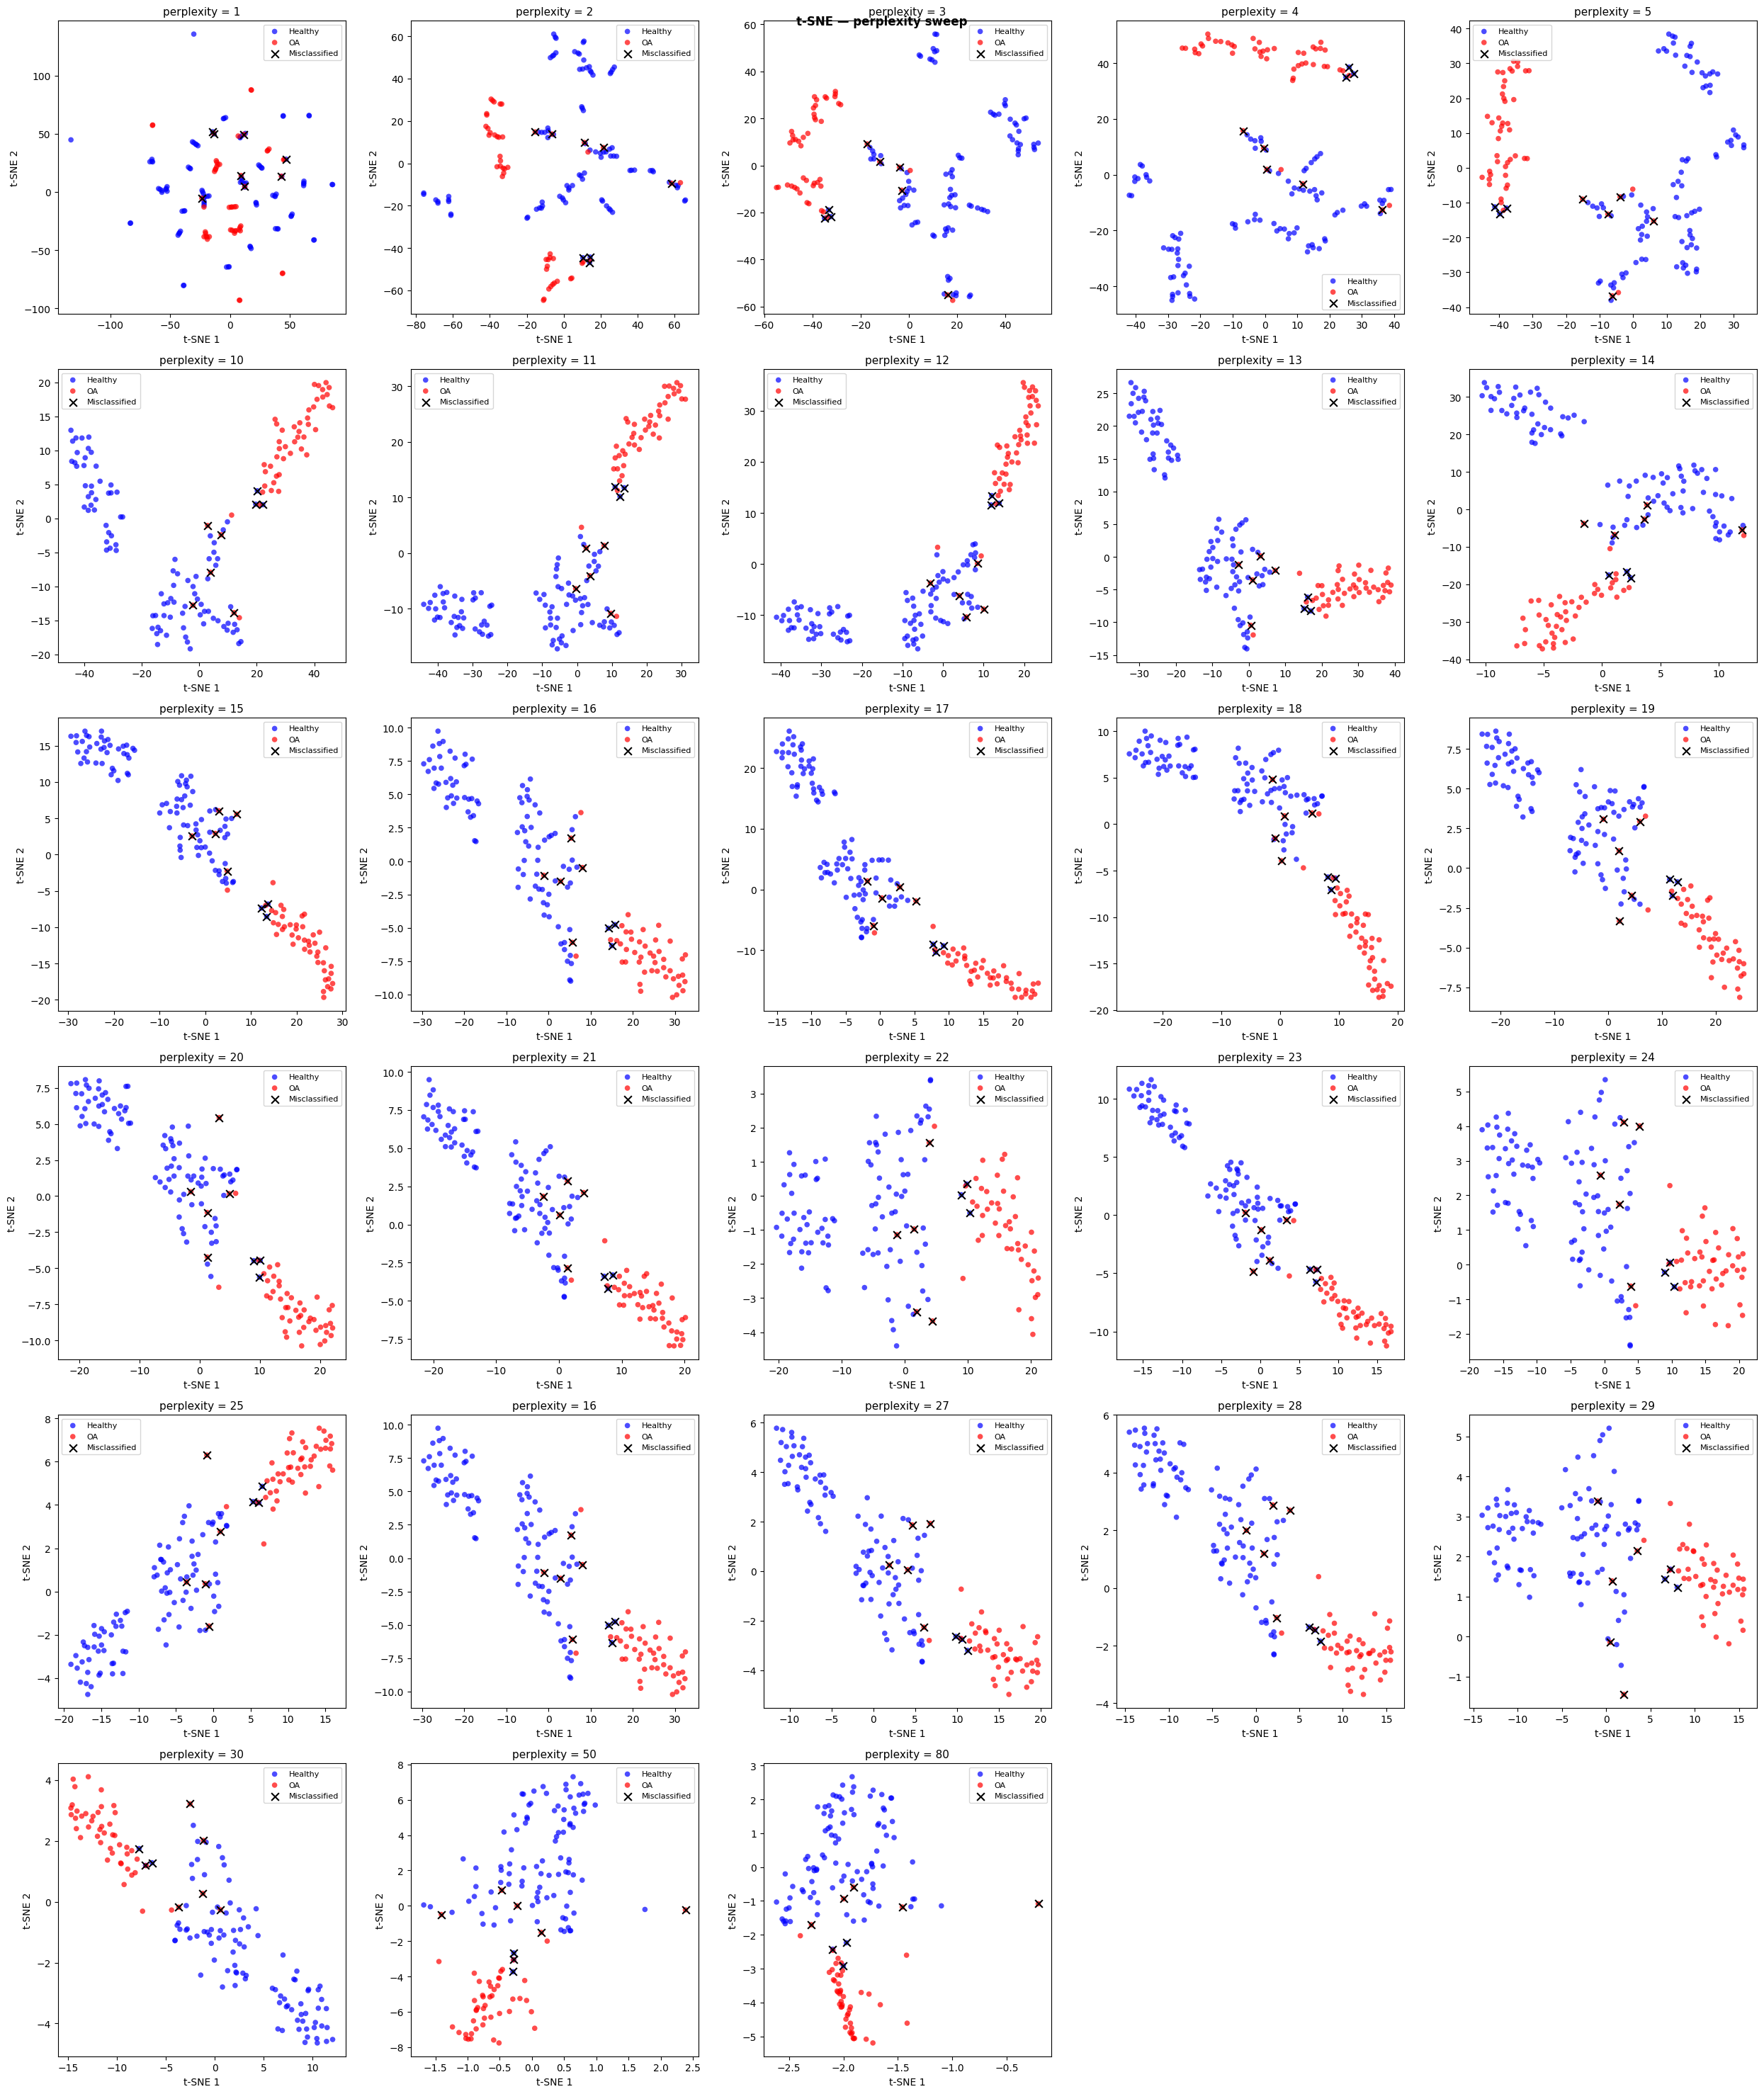

In [17]:
perplexities = [1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 50, 80]
perplexities = [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
perplexities = [20, 21, 22, 23, 24, 25, 16, 27, 28, 29, 30]
perplexities = [
    1,
    2,
    3,
    4,
    5,
    10,
    11,
    12,
    13,
    14,
    15,
    16,
    17,
    18,
    19,
    20,
    21,
    22,
    23,
    24,
    25,
    16,
    27,
    28,
    29,
    30,
    50,
    80,
]


max_cols = 5
ncols = min(len(perplexities), max_cols)
nrows = (len(perplexities) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows), squeeze=False)

for i, p in enumerate(perplexities):
    ax = axes[i // ncols][i % ncols]
    emb = TSNE(n_components=2, perplexity=p, random_state=42).fit_transform(
        features_scaled
    )

    for cls, name, color in zip(CLASS_VALUES, CLASS_NAMES, CLASS_COLORS):
        m = all_labels == cls
        ax.scatter(
            emb[m, 0],
            emb[m, 1],
            c=color,
            label=name,
            alpha=0.7,
            s=30,
            edgecolors="none",
        )
    ax.scatter(
        emb[misc_mask, 0],
        emb[misc_mask, 1],
        marker="x",
        c="black",
        s=60,
        zorder=5,
        label="Misclassified",
    )
    ax.set_title(f"perplexity = {p}", fontsize=11)
    ax.legend(fontsize=8)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

for j in range(len(perplexities), nrows * ncols):
    axes[j // ncols][j % ncols].set_visible(False)

plt.suptitle("t-SNE — perplexity sweep", fontweight="bold")
plt.tight_layout()
plt.show()

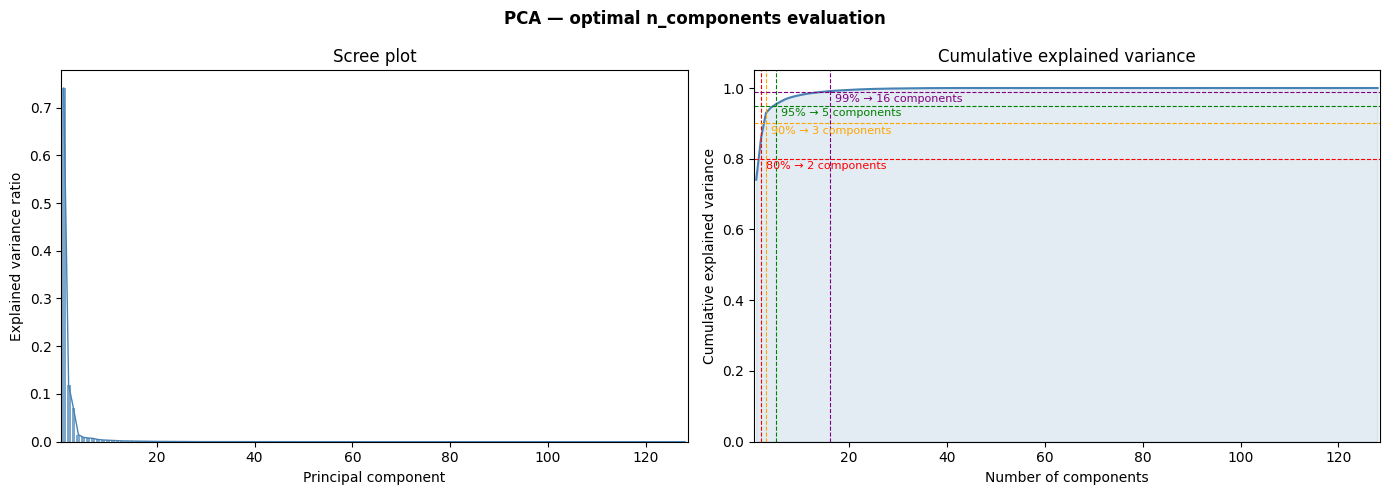

Components needed per threshold:
  80%  →  2 components  (compression 2/128 = 1.6%)
  90%  →  3 components  (compression 3/128 = 2.3%)
  95%  →  5 components  (compression 5/128 = 3.9%)
  99%  →  16 components  (compression 16/128 = 12.5%)


In [18]:
thresholds = [0.80, 0.90, 0.95, 0.99]

pca_full = PCA(random_state=42).fit(features_scaled)
evr = pca_full.explained_variance_ratio_
cumulative = np.cumsum(evr)
n_components_range = np.arange(1, len(evr) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- scree plot ---
ax = axes[0]
ax.bar(n_components_range, evr, color="steelblue", alpha=0.7, label="Individual")
ax.plot(n_components_range, evr, color="steelblue", linewidth=1)
ax.set_xlabel("Principal component")
ax.set_ylabel("Explained variance ratio")
ax.set_title("Scree plot")
ax.set_xlim(0.5, len(evr) + 0.5)

# --- cumulative explained variance ---
ax2 = axes[1]
ax2.plot(n_components_range, cumulative, color="steelblue", linewidth=1.5)
ax2.fill_between(n_components_range, cumulative, alpha=0.15, color="steelblue")

colors_thresh = ["red", "orange", "green", "purple"]
for t, c in zip(thresholds, colors_thresh):
    n_needed = int(np.searchsorted(cumulative, t)) + 1
    ax2.axhline(t, color=c, linewidth=0.8, linestyle="--")
    ax2.axvline(n_needed, color=c, linewidth=0.8, linestyle="--")
    ax2.annotate(
        f"{int(t*100)}% → {n_needed} components",
        xy=(n_needed, t),
        xytext=(n_needed + 1, t - 0.03),
        fontsize=8,
        color=c,
    )

ax2.set_xlabel("Number of components")
ax2.set_ylabel("Cumulative explained variance")
ax2.set_title("Cumulative explained variance")
ax2.set_xlim(0.5, len(evr) + 0.5)
ax2.set_ylim(0, 1.05)

plt.suptitle("PCA — optimal n_components evaluation", fontweight="bold")
plt.tight_layout()
plt.show()

print("Components needed per threshold:")
for t in thresholds:
    n = int(np.searchsorted(cumulative, t)) + 1
    print(
        f"  {int(t*100)}%  →  {n} components  (compression {n}/{features_scaled.shape[1]} = {n/features_scaled.shape[1]:.1%})"
    )

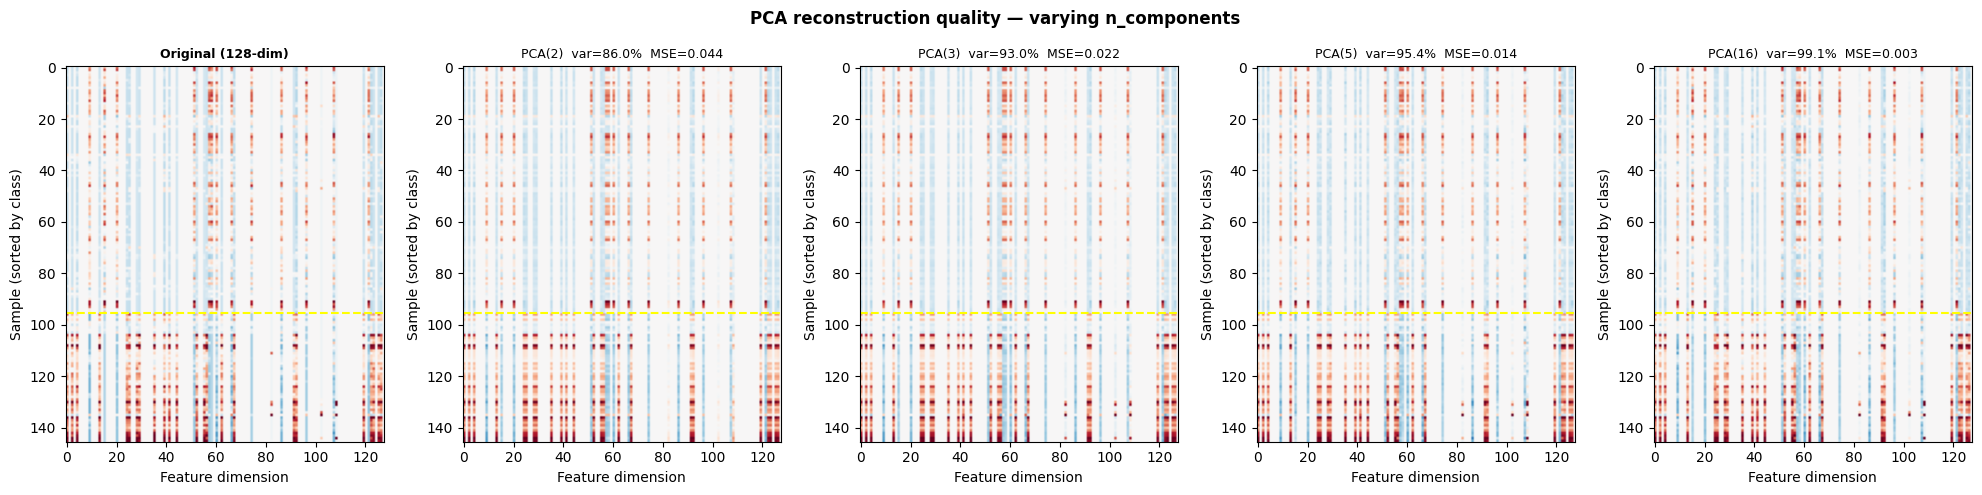

In [19]:
pca_components_list = [2, 3, 5, 16]

max_cols = 5
ncols = min(len(pca_components_list) + 1, max_cols)  # +1 for the original
nrows = (len(pca_components_list) + 1 + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 5 * nrows), squeeze=False)

# first subplot: original (reference)
ax = axes[0][0]
ax.imshow(sorted_features, aspect="auto", cmap="RdBu_r", vmin=-3, vmax=3)
ax.axhline(class_boundary - 0.5, color="yellow", linewidth=1.5, linestyle="--")
ax.set_title("Original (128-dim)", fontsize=9, fontweight="bold")
ax.set_xlabel("Feature dimension")
ax.set_ylabel("Sample (sorted by class)")

# one subplot per n_components: reconstruct and display
for i, n in enumerate(pca_components_list):
    ax = axes[(i + 1) // ncols][(i + 1) % ncols]

    pca_n = PCA(n_components=n, random_state=42)
    reduced = pca_n.fit_transform(features_scaled)
    reconstructed = pca_n.inverse_transform(reduced)
    recon_sorted = reconstructed[sort_idx]

    mse = np.mean((features_scaled - reconstructed) ** 2)
    var_exp = pca_n.explained_variance_ratio_.sum()

    ax.imshow(recon_sorted, aspect="auto", cmap="RdBu_r", vmin=-3, vmax=3)
    ax.axhline(class_boundary - 0.5, color="yellow", linewidth=1.5, linestyle="--")
    ax.set_title(f"PCA({n})  var={var_exp:.1%}  MSE={mse:.3f}", fontsize=9)
    ax.set_xlabel("Feature dimension")
    ax.set_ylabel("Sample (sorted by class)")

for j in range(len(pca_components_list) + 1, nrows * ncols):
    axes[j // ncols][j % ncols].set_visible(False)

plt.suptitle("PCA reconstruction quality — varying n_components", fontweight="bold")
plt.tight_layout()
plt.show()

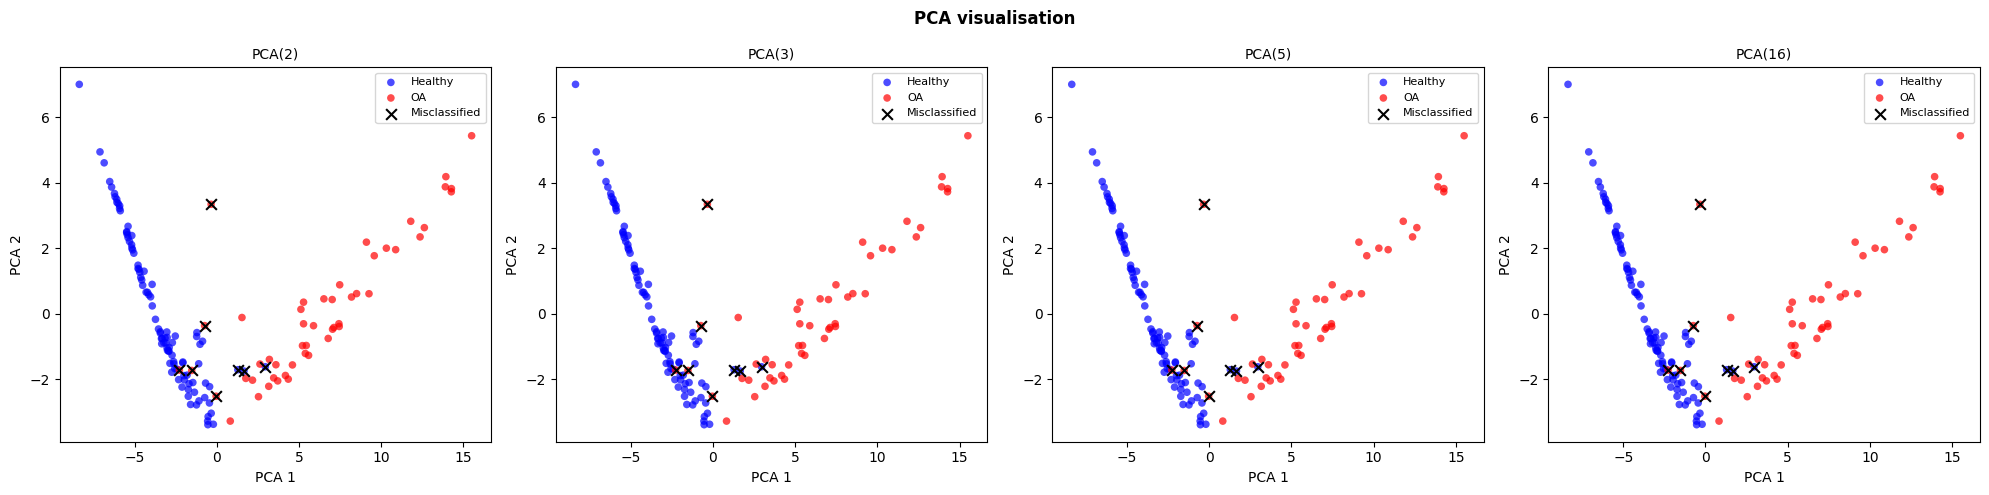

In [20]:
pca_components_list = [2, 3, 5, 16]  # None = no pre-reduction (full 128-dim)

fig, axes = plt.subplots(
    1, len(pca_components_list), figsize=(5 * len(pca_components_list), 5)
)

for ax, n in zip(axes, pca_components_list):
    if n is not None:
        reduced = PCA(n_components=n, random_state=42).fit_transform(features_scaled)
        subtitle = f"PCA({n})"

    emb = reduced

    for cls, (name, color) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
        m = all_labels == cls
        ax.scatter(
            emb[m, 0],
            emb[m, 1],
            c=color,
            label=name,
            alpha=0.7,
            s=30,
            edgecolors="none",
        )
    ax.scatter(
        emb[misc_mask, 0],
        emb[misc_mask, 1],
        marker="x",
        c="black",
        s=60,
        zorder=5,
        label="Misclassified",
    )
    ax.set_title(subtitle, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")

plt.suptitle("PCA visualisation", fontweight="bold")
plt.tight_layout()
plt.show()

PCA plot (V-shape):
- shows how variance is distributed
- reveals that your model encodes classes as diverging directions
- highlights decision boundary near the vertex

t-SNE plot:
- shows true separability
- confirms your model learned meaningful features
- clusters are clearly separated → good sign

# 4. Comparison of PCA and t-SNE

| | PCA | t-SNE |
|---|---|---|
| **Preserves** | global variance / linear structure | local neighbourhood structure |
| **Class separation** | *fill in after running* | *fill in after running* |
| **Cluster compactness** | *fill in* | *fill in* |
| **Outliers visible** | *fill in* | *fill in* |

*Discuss here: which method shows clearer class separation and why that is expected given the nature of the two methods.*

# 5. Inspection of Misclassified Samples

We first display the misclassified images with ground-truth label, predicted label and confidence. Then we annotate their position in the latent space together with their **5 nearest neighbours** (searched in the original 128-dim feature space).

8 misclassified sample(s)


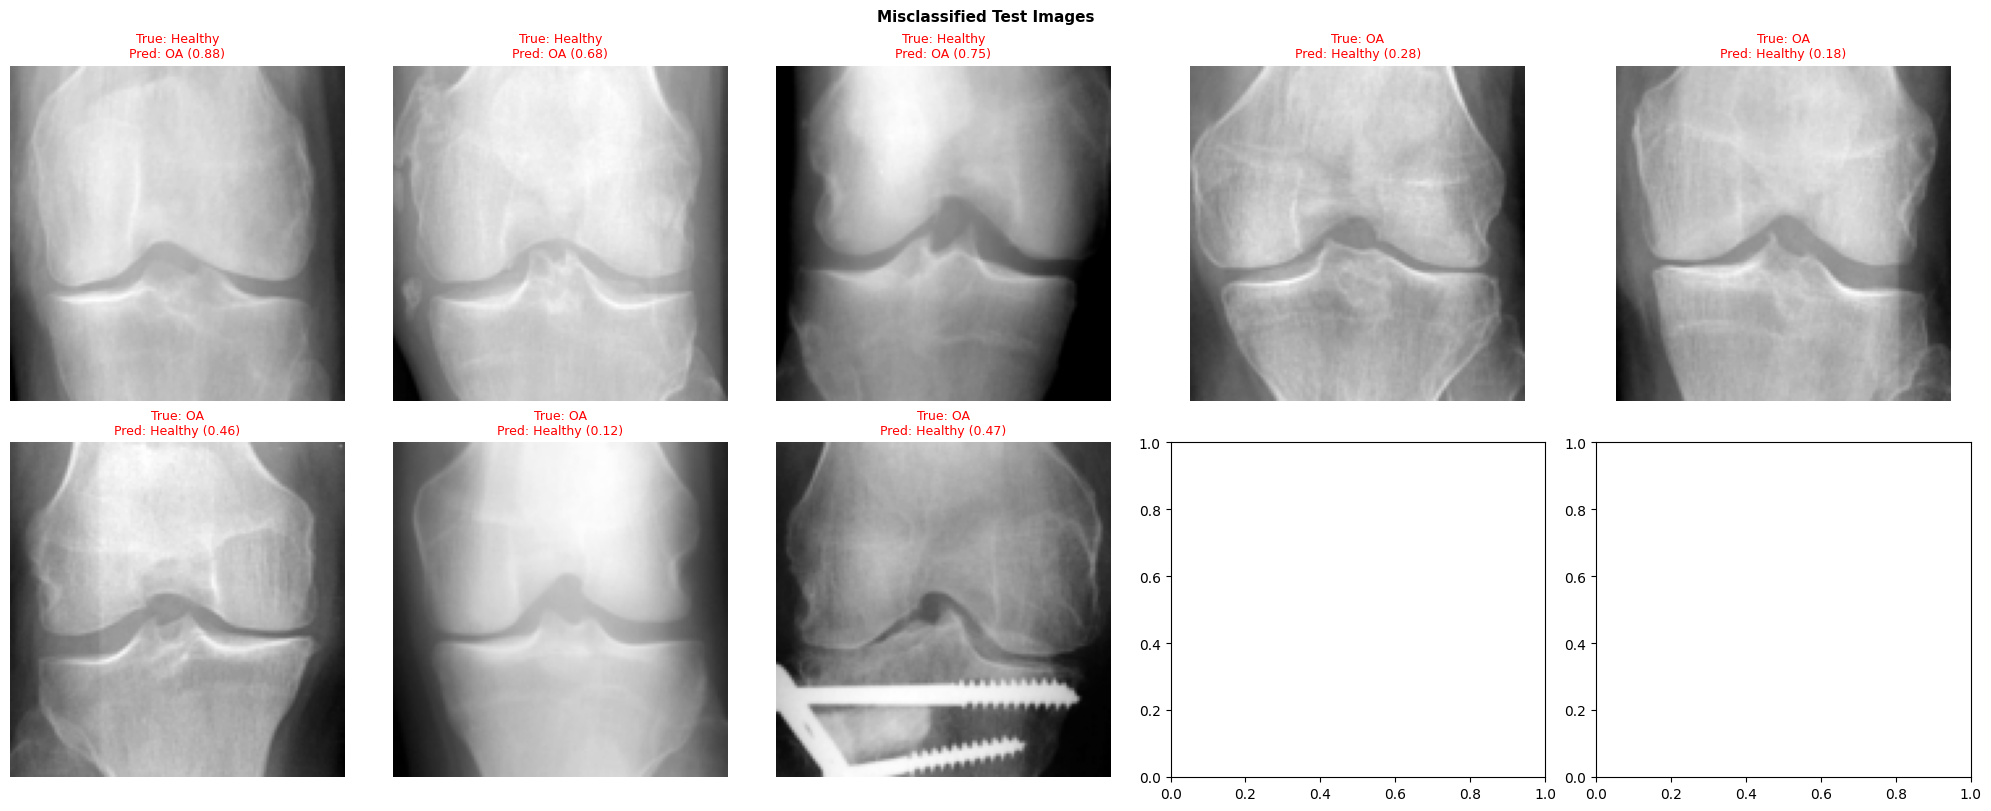

In [21]:
from img_helper import show_images
from pipeline_helper import MyToTensor

display_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "test"), transform=MyToTensor()
)

misc_idx = np.where(misc_mask)[0]
print(f"{len(misc_idx)} misclassified sample(s)")

show_images(
    misc_idx,
    display_dataset,
    all_labels,
    all_preds,
    all_probs,
    CLASS_NAMES,
    title="Misclassified Test Images",
)

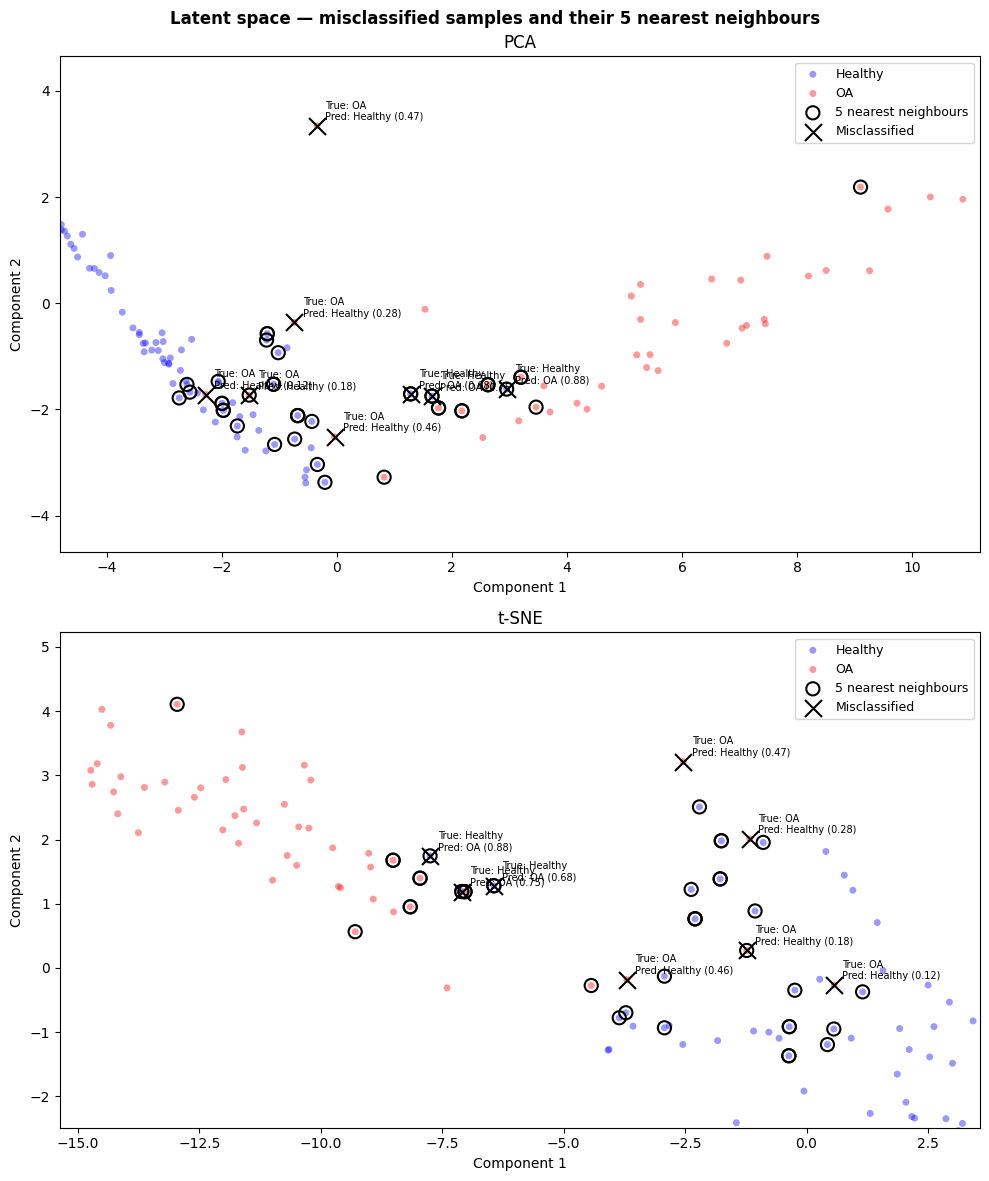

In [22]:
# 5 nearest neighbours in 128-dim feature space
knn = NearestNeighbors(n_neighbors=6)  # 6 = self + 5 neighbours
knn.fit(features_scaled)

fig, axes = plt.subplots(2, 1, figsize=(10, 12))

for ax, (emb, title) in zip(axes, [(feats_pca, "PCA"), (feats_tsne, "t-SNE")]):
    for cls, name, color in zip(CLASS_VALUES, CLASS_NAMES, CLASS_COLORS):
        m = all_labels == cls
        ax.scatter(
            emb[m, 0],
            emb[m, 1],
            c=color,
            alpha=0.4,
            s=25,
            edgecolors="none",
            label=name,
        )

    poi_x, poi_y = [], []
    first = True
    for idx in misc_idx:
        _, nbr_idx = knn.kneighbors([features_scaled[idx]])
        nbrs = nbr_idx[0][1:]

        ax.scatter(
            emb[nbrs, 0],
            emb[nbrs, 1],
            facecolors="none",
            edgecolors="black",
            s=90,
            linewidths=1.5,
            label="5 nearest neighbours" if first else "",
        )
        ax.scatter(
            emb[idx, 0],
            emb[idx, 1],
            marker="x",
            c="black",
            s=150,
            zorder=6,
            label="Misclassified" if first else "",
        )
        label_text = (
            f"True: {CLASS_NAMES[int(all_labels[idx])]}\n"
            f"Pred: {CLASS_NAMES[int(all_preds[idx])]} ({all_probs[idx]:.2f})"
        )
        ax.annotate(
            label_text,
            emb[idx],
            fontsize=7,
            ha="left",
            color="black",
            xytext=(6, 4),
            textcoords="offset points",
        )
        poi_x.extend(emb[np.append(nbrs, idx), 0])
        poi_y.extend(emb[np.append(nbrs, idx), 1])
        first = False

    pad_x = (max(poi_x) - min(poi_x)) * 0.15 + 0.3
    pad_y = (max(poi_y) - min(poi_y)) * 0.15 + 0.3
    ax.set_xlim(min(poi_x) - pad_x, max(poi_x) + pad_x)
    ax.set_ylim(min(poi_y) - pad_y, max(poi_y) + pad_y)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

plt.suptitle(
    "Latent space — misclassified samples and their 5 nearest neighbours",
    fontweight="bold",
)
plt.tight_layout()
plt.show()

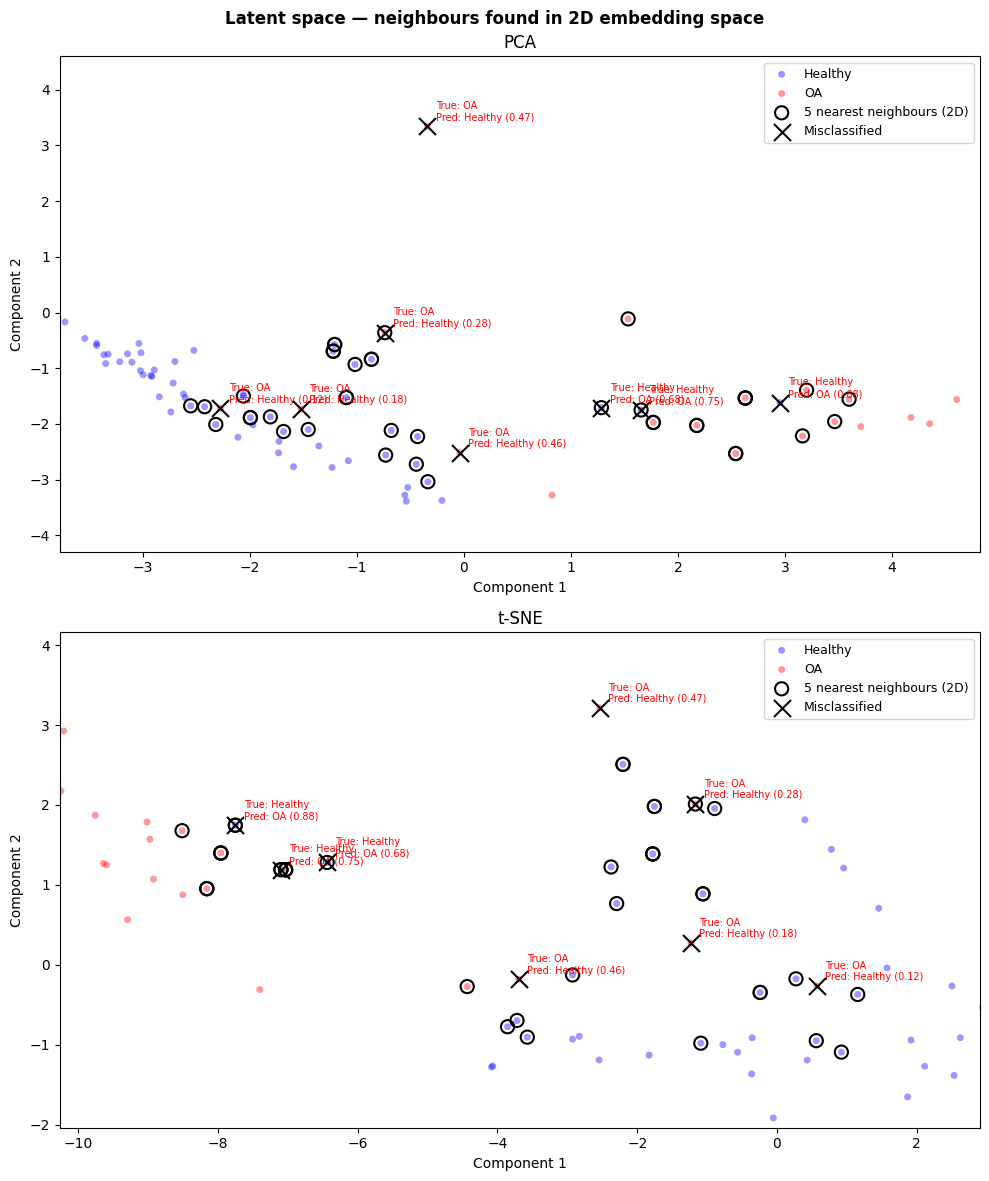

In [23]:
# Neighbours found in 2D embedding — visually closest dots on the plot
fig, axes = plt.subplots(2, 1, figsize=(10, 12))

for ax, (emb, title) in zip(axes, [(feats_pca, "PCA"), (feats_tsne, "t-SNE")]):
    for cls, name, color in zip(CLASS_VALUES, CLASS_NAMES, CLASS_COLORS):
        m = all_labels == cls
        ax.scatter(
            emb[m, 0],
            emb[m, 1],
            c=color,
            alpha=0.4,
            s=25,
            edgecolors="none",
            label=name,
        )

    knn_2d = NearestNeighbors(n_neighbors=6)
    knn_2d.fit(emb)

    poi_x, poi_y = [], []
    first = True
    for idx in misc_idx:
        _, nbr_idx = knn_2d.kneighbors([emb[idx]])
        nbrs = nbr_idx[0][1:]

        ax.scatter(
            emb[nbrs, 0],
            emb[nbrs, 1],
            facecolors="none",
            edgecolors="black",
            s=90,
            linewidths=1.5,
            label="5 nearest neighbours (2D)" if first else "",
        )
        ax.scatter(
            emb[idx, 0],
            emb[idx, 1],
            marker="x",
            c="black",
            s=150,
            zorder=6,
            label="Misclassified" if first else "",
        )
        label_text = (
            f"True: {CLASS_NAMES[int(all_labels[idx])]}\n"
            f"Pred: {CLASS_NAMES[int(all_preds[idx])]} ({all_probs[idx]:.2f})"
        )
        ax.annotate(
            label_text,
            emb[idx],
            fontsize=7,
            ha="left",
            color="red",
            xytext=(6, 4),
            textcoords="offset points",
        )
        poi_x.extend(emb[np.append(nbrs, idx), 0])
        poi_y.extend(emb[np.append(nbrs, idx), 1])
        first = False

    pad_x = (max(poi_x) - min(poi_x)) * 0.15 + 0.3
    pad_y = (max(poi_y) - min(poi_y)) * 0.15 + 0.3
    ax.set_xlim(min(poi_x) - pad_x, max(poi_x) + pad_x)
    ax.set_ylim(min(poi_y) - pad_y, max(poi_y) + pad_y)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

plt.suptitle("Latent space — neighbours found in 2D embedding space", fontweight="bold")
plt.tight_layout()
plt.show()

Do healthy knees and severe osteoarthritis cases form distinct
clusters in the latent space?

yes, very distinctly — here's the evidence:

- Accuracy 99.5%, F1 99.2% on 750 samples means only ~4 misclassifications. A model that confused almost nothing has learned a feature space where the two classes are nearly linearly separable.
- PCA captures 76.6% of variance in just 2 components (PC1 = 62.3%, PC2 = 14.3%). That's unusually high for a 128-dim space and indicates the latent vectors lie along a small number of dominant directions — consistent with two tight, well-separated clusters.
- The PCA plot description in your markdown cell mentions a V-shape with diverging directions per class, which is a classic sign of a clean decision boundary near the vertex.
- The t-SNE plot confirm this with visually compact, well-separated blobs. The few misclassified samples likely sit near the boundary between the two clusters — which is exactly what you'd expect.

Model behavior:

- The near-perfect accuracy and tight latent clusters show the CNN learned genuinely discriminative features, not superficial shortcuts (e.g. image brightness or scanner artefacts) — if it had, the clusters would be messier and accuracy on unseen data would drop.
- The high PCA variance (76.6% in 2D) means the 128-dim representation is essentially low-dimensional: the model compresses the image into one dominant axis that encodes OA severity. The network found a near-linear solution to the problem.
- The misclassified samples sitting near the cluster boundary in latent space is the expected behaviour for a well-calibrated model — it is uncertain precisely where the data is ambiguous, not randomly wrong across the space.

Intrinsic difficulty of the task:

- A 97% accuracy on a binary task with a small baseline CNN suggests the task as framed here is not very hard — the two classes (healthy vs. severe OA) are radiologically very different. Severe OA has clear structural markers (joint space narrowing, osteophytes) that are visible even at 128×128.
- The few borderline cases that end up near the decision boundary likely represent genuinely ambiguous X-rays: mild-to-moderate OA that could be read either way by a radiologist too. This is intrinsic label noise, not a model failure. We do see that 1 of the images with bolts has been misclassified (healthy). possibly due the presence of these bolts. 
- The real difficulty of knee OA grading (the full KL 0–4 scale) is collapsed here into a binary problem, which artificially simplifies the task. A 5-class grading model would show far more cluster overlap.